In [ ]:
extracted phased data 

In [6]:
import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr6_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 476 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr6 positions from your BED
chrom = "chr6"
positions = [31575254, 135097495, 135097526, 135097880]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=64
)

# Filter to your loci + your 476 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.4pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:33003
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr6_481.log
2026-06-11 11:43:54.120 Hail: INFO: Reading table without type imputation1) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr6_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-11 11:44:02.108 Hail: INFO: scanning VCF for sortedness...
2026-06-11 19:41:08.218 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 3 cols: 481


2026-06-11 20:09:15.544 Hail: INFO: merging 3 files totalling 23.3K... + 1) / 2]
2026-06-11 20:09:16.109 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr6.481.4pos.phased.vcf.bgz
  merge time: 563.448ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr6.481.4pos.phased.vcf.bgz


In [9]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr6.481.4pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr6	31575254	G	A
chr6	135097526	GC	CC,G
chr6	135097880	T	C



In [3]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr6.481.4pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr6 = pd.DataFrame(rows)

df_chr6

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr6,31575254,G,A,0|0,0|0,0|0,0|0,0|0,0|0,...,0|0,1|0,0|0,0|0,0|0,0|0,1|0,0|0,0|0,0|0
1,chr6,135097526,GC,"CC,G",1|0,0|0,0|0,0|0,0|0,0|0,...,0|0,1|0,0|0,0|0,0|0,0|1,0|0,0|0,0|0,0|0
2,chr6,135097880,T,C,0|0,0|0,0|0,1|0,0|0,0|1,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0


In [4]:
df_chr6.to_csv("chr6_481_genotypes_wide.csv", index=False)
print("Saved: chr6_481_genotypes_wide.csv")

Saved: chr6_481_genotypes_wide.csv


In [2]:
import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr22_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 481 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr22 positions from your BED
chrom = "chr22"
positions = [36265860, 36265988, 36265996]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=64
)

# Filter to your loci + your 476 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.3pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:33221
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr22_481.log
2026-06-12 11:50:25.418 Hail: INFO: Reading table without type imputation1) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr22_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-12 11:50:33.681 Hail: INFO: scanning VCF for sortedness...
2026-06-12 14:00:18.241 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 3 cols: 481


2026-06-12 14:21:00.564 Hail: INFO: merging 2 files totalling 23.2K... + 1) / 1]
2026-06-12 14:21:01.075 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr22.481.3pos.phased.vcf.bgz
  merge time: 508.030ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr22.481.3pos.phased.vcf.bgz


In [3]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr22.481.3pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr22	36265860	A	G
chr22	36265988	T	G
chr22	36265996	ATAATT	A,GTAATT



In [4]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr22.481.3pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr22 = pd.DataFrame(rows)

df_chr22

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr22,36265860,A,G,0|0,0|1,0|0,0|0,1|1,0|0,...,0|0,0|0,1|0,0|0,0|0,0|1,0|1,1|0,0|0,0|0
1,chr22,36265988,T,G,0|0,0|1,0|0,0|0,1|0,0|0,...,0|0,0|0,1|0,0|0,0|0,0|1,0|1,1|0,0|0,0|0
2,chr22,36265996,ATAATT,"A,GTAATT",0|0,0|0,0|0,0|0,0|0,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0


In [7]:
df_chr22.to_csv("chr22_481_genotypes_wide.csv", index=False)
print("Saved: chr22_481_genotypes_wide.csv")

Saved: chr22_481_genotypes_wide.csv


In [5]:
import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr19_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 481 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr19 positions from your BED
chrom = "chr19"
positions = [44908684, 44908822]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=64
)

# Filter to your loci + your 476 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.2pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:41731
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr19_481.log
2026-06-12 16:49:19.453 Hail: INFO: Reading table without type imputation0) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr19_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-12 16:49:27.969 Hail: INFO: scanning VCF for sortedness...
2026-06-12 20:12:03.042 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 2 cols: 481


2026-06-12 20:32:27.801 Hail: INFO: merging 2 files totalling 23.2K... + 1) / 1]
2026-06-12 20:32:28.154 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz
  merge time: 351.596ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz


In [6]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr19	44908684	T	C
chr19	44908822	C	A,T



In [7]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr19 = pd.DataFrame(rows)

df_chr19

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr19,44908684,T,C,0|0,0|0,0|0,0|0,0|0,0|0,...,0|0,0|1,0|0,0|0,0|0,1|0,1|0,1|0,0|0,0|1
1,chr19,44908822,C,"A,T",0|0,0|0,0|0,0|0,0|0,0|0,...,2|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,2|0


In [8]:
df_chr19.to_csv("chr19_481_genotypes_wide.csv", index=False)
print("Saved: chr19_481_genotypes_wide.csv")

Saved: chr19_481_genotypes_wide.csv


In [1]:
import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr2_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 481 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr12 positions from your BED
chrom = "chr2"
positions = [60487726, 60490908, 60498316]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=64
)

# Filter to your loci + your 481 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.3pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:33385
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr2_481.log
2026-06-15 09:55:48.564 Hail: INFO: Reading table without type imputation1) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr2_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-15 09:55:57.016 Hail: INFO: scanning VCF for sortedness...
2026-06-15 21:20:10.494 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 3 cols: 481


2026-06-15 21:42:04.291 Hail: INFO: merging 2 files totalling 23.6K... + 1) / 1]
2026-06-15 21:42:04.652 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz
  merge time: 359.233ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz


2026-06-15 21:43:06.732 Hail: INFO: Reading table without type imputation
  Loading field 'f0' as type str (not specified)
2026-06-15 21:43:12.450 Hail: INFO: scanning VCF for sortedness...


In [2]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr2	60487726	A	C
chr2	60490908	T	G
chr2	60498316	G	A,C



In [3]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr2 = pd.DataFrame(rows)

df_chr2

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr2,60487726,A,C,1|1,0|0,0|0,0|0,0|1,1|1,...,1|1,0|0,1|0,0|1,0|1,1|0,1|0,1|0,1|1,1|0
1,chr2,60490908,T,G,1|1,1|1,0|1,0|0,1|1,1|1,...,1|1,1|0,1|0,0|1,1|1,1|0,1|1,1|1,1|1,1|1
2,chr2,60498316,G,"A,C",0|0,2|2,0|2,0|0,0|0,2|2,...,0|0,2|0,0|0,0|0,2|0,0|0,0|2,0|2,0|0,0|2


In [4]:
df_chr2.to_csv("chr2_481_genotypes_wide.csv", index=False)
print("Saved: chr2_481_genotypes_wide.csv")

Saved: chr2_481_genotypes_wide.csv


In [1]:
import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr11_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 481 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr11 positions from your BED
chrom = "chr11"
positions = [5239228, 5242453, 5248569, 5254939]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=64
)

# Filter to your loci + your 481 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.4pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:42781
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr11_481.log
2026-06-16 04:43:38.400 Hail: INFO: Reading table without type imputation1) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr11_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-16 04:43:47.516 Hail: INFO: scanning VCF for sortedness...
2026-06-16 12:06:31.555 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 4 cols: 481


2026-06-16 12:24:46.316 Hail: INFO: merging 2 files totalling 23.5K... + 1) / 1]
2026-06-16 12:24:46.655 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz
  merge time: 337.950ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz


In [2]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr11	5239228	T	C
chr11	5242453	C	T
chr11	5248569	A	C,T
chr11	5254939	G	A



In [3]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr11 = pd.DataFrame(rows)

df_chr11

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr11,5239228,T,C,1|0,0|0,0|0,0|0,1|0,0|1,...,0|0,0|1,0|0,0|1,0|0,0|0,0|0,0|0,1|1,0|0
1,chr11,5242453,C,T,0|1,0|0,0|0,0|0,0|0,1|0,...,0|0,0|0,0|1,0|0,0|0,0|0,0|0,0|0,0|0,0|0
2,chr11,5248569,A,"C,T",1|1,1|1,1|1,0|0,1|1,1|1,...,1|1,1|1,1|1,1|1,1|1,1|1,1|0,0|1,1|1,1|1
3,chr11,5254939,G,A,0|1,0|0,0|0,0|0,0|0,1|0,...,0|0,0|0,0|1,0|0,0|0,0|0,0|0,0|0,0|0,0|0


In [4]:
df_chr11.to_csv("chr11_481_genotypes_wide.csv", index=False)
print("Saved: chr11_481_genotypes_wide.csv")

Saved: chr11_481_genotypes_wide.csv


In [1]:
# import os
import hail as hl

GOOGLE_PROJECT="wb-happy-haricot-6587"
WORKSPACE_BUCKET="gs://sickle-cell-cohort-wb-happy-haricot-6587"

PHASE_DIR = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing"
OUT_DIR   = f"{WORKSPACE_BUCKET}/outputs/phased_17pos_481"
TMP_DIR   = f"{WORKSPACE_BUCKET}/hail_tmp"
LOG_PATH  = f"{WORKSPACE_BUCKET}/logs/hail_subset_chr1_481.log"

# Init Hail (Spark backend) + requester pays
hl.init(
    default_reference="GRCh38",
    tmp_dir=TMP_DIR,
    log=LOG_PATH,
    idempotent=True,
    gcs_requester_pays_configuration=(GOOGLE_PROJECT, ["vwb-aou-datasets-controlled"]),
)

# 481 keep list
keep_path = f"{WORKSPACE_BUCKET}/inputs/scd_participants_iid.481.txt"
keep_ht = hl.import_table(keep_path, no_header=True).rename({'f0': 's'}).key_by('s')

# chr1 positions from your BED
chrom = "chr1"
positions = [100718269]

target_loci = hl.literal({
    hl.parse_locus(f"{chrom}:{p}", reference_genome="GRCh38")
    for p in positions
})

vcf_path = f"{PHASE_DIR}/{chrom}_AOU_v8.2_allsamples_phased.vcf.gz"
print("Reading:", vcf_path)

mt = hl.import_vcf(
    vcf_path,
    reference_genome="GRCh38",
    force_bgz=True,
    min_partitions=128
)

# Filter to your loci + your 476 samples
mt = mt.filter_rows(target_loci.contains(mt.locus))
mt = mt.filter_cols(hl.is_defined(keep_ht[mt.s]))

# Keep only genotype calls (smaller output)
mt = mt.select_entries("GT")

print("rows:", mt.count_rows(), "cols:", mt.count_cols())

out_vcf = f"{OUT_DIR}/{chrom}.481.1pos.phased.vcf.bgz"
hl.export_vcf(mt, out_vcf, tabix=True)

print(" Wrote:", out_vcf)

Loading BokehJS ...

/opt/conda/miniconda3/lib/python3.11/site-packages/hail/context.py:354: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

Running on Apache Spark version 3.5.3
SparkUI available at http://jupyterlabsparkclusterforaouspark20260611-m.us-central1-a.c.wb-happy-haricot-6587.internal:46851
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.135-034ef3e08116
LOGGING: writing to gs://sickle-cell-cohort-wb-happy-haricot-6587/logs/hail_subset_chr1_481.log
2026-06-17 17:34:50.890 Hail: INFO: Reading table without type imputation1) / 1]
  Loading field 'f0' as type str (not specified)


Reading: gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/phasing/chr1_AOU_v8.2_allsamples_phased.vcf.gz


2026-06-17 17:35:00.395 Hail: INFO: scanning VCF for sortedness...
2026-06-18 04:06:17.481 Hail: INFO: Coerced sorted VCF - no additional import work to do


rows: 1 cols: 481


2026-06-18 04:28:31.953 Hail: INFO: merging 2 files totalling 23.1K... + 1) / 1]
2026-06-18 04:28:32.341 Hail: INFO: while writing:
    gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz
  merge time: 385.590ms


 Wrote: gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz


In [2]:
import subprocess

cmd = """
zcat outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz \
| grep -v '^#' \
| cut -f1,2,4,5
"""

print(subprocess.check_output(cmd, shell=True, text=True))

chr1	100718269	T	C



In [4]:
import pandas as pd
import gzip

vcf_path = "outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz"

# -------------------------
# Read VCF
# -------------------------
rows = []
samples = []

with gzip.open(vcf_path, "rt") as f:
    for line in f:
        line = line.strip()

        # meta lines
        if line.startswith("##"):
            continue

        # header line (sample names)
        if line.startswith("#CHROM"):
            header = line.split("\t")
            samples = header[9:]   # sample IDs start here
            continue

        # variant lines
        parts = line.split("\t")

        chrom = parts[0]
        pos = int(parts[1])
        ref = parts[3]
        alt = parts[4]
        gts = parts[9:]  # genotype fields

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        # map sample → genotype
        row.update({samples[i]: gts[i] for i in range(len(samples))})

        rows.append(row)

df_chr1 = pd.DataFrame(rows)

df_chr1

,CHROM,POS,REF,ALT,1006406,1010745,1016320,1020248,1031989,1039945,...,9233841,9268898,9372979,9516264,9613057,9693583,9817511,9834243,9938486,9980176
0,chr1,100718269,T,C,0|1,0|0,0|0,0|0,0|0,0|0,...,0|0,0|0,0|0,0|0,0|0,1|0,0|0,1|0,0|1,0|0


In [5]:
df_chr1.to_csv("chr1_481_genotypes_wide.csv", index=False)
print("Saved: chr1_481_genotypes_wide.csv")

Saved: chr1_481_genotypes_wide.csv


In [3]:
%%bash
set -euo pipefail
gsutil ls "gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/"

gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz.tbi
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz.tbi
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz.tbi
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr2.481.3pos.phased.vcf.bgz.tbi
gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr22.481.3pos.phased.vcf.bgz
gs://si

In [2]:
%%bash
ls -1 *.vcf.bgz

chr11.481.4pos.phased.vcf.bgz
chr1.481.1pos.phased.vcf.bgz
chr19.481.2pos.phased.vcf.bgz
chr22.481.3pos.phased.vcf.bgz
chr2.481.3pos.phased.vcf.bgz
chr6.481.4pos.phased.vcf.bgz


In [3]:
%%bash
set -euo pipefail

BASE="gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481"

# Download VCFs and their tabix indexes
gsutil -m cp "${BASE}/chr1"*.vcf.bgz .
gsutil -m cp "${BASE}/chr1"*.vcf.bgz.tbi .

gsutil -m cp "${BASE}/chr2"*.vcf.bgz .
gsutil -m cp "${BASE}/chr2"*.vcf.bgz.tbi .

gsutil -m cp "${BASE}/chr6"*.vcf.bgz .
gsutil -m cp "${BASE}/chr6"*.vcf.bgz.tbi .

gsutil -m cp "${BASE}/chr11"*.vcf.bgz .
gsutil -m cp "${BASE}/chr11"*.vcf.bgz.tbi .

gsutil -m cp "${BASE}/chr19"*.vcf.bgz .
gsutil -m cp "${BASE}/chr19"*.vcf.bgz.tbi .

gsutil -m cp "${BASE}/chr22"*.vcf.bgz .
gsutil -m cp "${BASE}/chr22"*.vcf.bgz.tbi .

# Merge chromosomes
bcftools concat -a -Oz -o merged.481.vcf.gz \
    chr1*.vcf.bgz \
    chr2*.vcf.bgz \
    chr6*.vcf.bgz \
    chr11*.vcf.bgz \
    chr19*.vcf.bgz \
    chr22*.vcf.bgz

# Index merged VCF
bcftools index -t merged.481.vcf.gz

# Sanity checks
echo "Samples:"
bcftools query -l merged.481.vcf.gz | wc -l

echo "Variants:"
bcftools view -H merged.481.vcf.gz | wc -l

echo "chr22:"
bcftools query -f '%CHROM\t%POS\n' -r chr22 merged.481.vcf.gz

Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz...
Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz...
Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz...
- [3/3 files][ 69.8 KiB/ 69.8 KiB] 100% Done                                    
Operation completed over 3 objects/69.8 KiB.                                     
Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr1.481.1pos.phased.vcf.bgz.tbi...
Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr11.481.4pos.phased.vcf.bgz.tbi...
Copying gs://sickle-cell-cohort-wb-happy-haricot-6587/outputs/phased_17pos_481/chr19.481.2pos.phased.vcf.bgz.tbi...
- [3/3 files][  446.0 B/  446.0 B] 100% Done                                    
Operation completed over 3 objects/446.0 B.                               

Samples:
481
Variants:
25
chr22:
chr22	36265860
chr22	36265860
chr22	36265988
chr22	36265988
chr22	36265996
chr22	36265996


In [4]:
%%bash
echo "Multiallelic variants:"
bcftools view -H merged.481.vcf.gz | awk '$5 ~ /,/'

Multiallelic variants:
chr11	5248569	.	A	C,T	.	.	.	GT	1|1	1|1	1|1	0|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|0	1|0	0|1	1|1	1|1	1|1	0|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	0|1	0|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	0|1	1|1	0|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	0|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|0	1|0	1|1	1|1	1|1	1|0	1|1	1|1	0|1	1|1	1|1	0|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	0|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	0|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	0|0	1|1	1|0	0|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|0	1|1	1|1	1|0	1|1	0|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|1	1|

In [5]:
%%bash
bcftools view -H merged.481.vcf.gz | awk '$5 ~ /,/' | wc -l

8


In [6]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' merged.481.vcf.gz | \
awk '$4 ~ /,/'

chr11	5248569	A	C,T
chr11	5248569	A	C,T
chr19	44908822	C	A,T
chr19	44908822	C	A,T
chr22	36265996	ATAATT	A,GTAATT
chr22	36265996	ATAATT	A,GTAATT
chr2	60498316	G	A,C
chr6	135097526	GC	CC,G


In [7]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' merged.481.vcf.gz

chr11	5239228	T	C
chr11	5239228	T	C
chr11	5242453	C	T
chr11	5242453	C	T
chr11	5248569	A	C,T
chr11	5248569	A	C,T
chr11	5254939	G	A
chr11	5254939	G	A
chr1	100718269	T	C
chr19	44908684	T	C
chr19	44908684	T	C
chr19	44908822	C	A,T
chr19	44908822	C	A,T
chr22	36265860	A	G
chr22	36265860	A	G
chr22	36265988	T	G
chr22	36265988	T	G
chr22	36265996	ATAATT	A,GTAATT
chr22	36265996	ATAATT	A,GTAATT
chr2	60487726	A	C
chr2	60490908	T	G
chr2	60498316	G	A,C
chr6	31575254	G	A
chr6	135097526	GC	CC,G
chr6	135097880	T	C


In [8]:
%%bash
bcftools norm \
    -m -both \
    -Oz \
    -o merged.481.biallelic.vcf.gz \
    merged.481.vcf.gz

bcftools index -t merged.481.biallelic.vcf.gz

Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	25/8/0/0/0/0/0


In [10]:
%%bash
echo "Original:"
bcftools view -H merged.481.vcf.gz | wc -l

echo "After split:"
bcftools view -H merged.481.biallelic.vcf.gz | wc -l

Original:
25
After split:
33


In [11]:
%%bash
bcftools query -f '%CHROM\t%POS\t%ALT\n' merged.481.vcf.gz | \
awk -F'\t' '
{
  n=split($3,a,",");
  if(n>1) print $1,$2,n
}'

chr11 5248569 2
chr11 5248569 2
chr19 44908822 2
chr19 44908822 2
chr22 36265996 2
chr22 36265996 2
chr2 60498316 2
chr6 135097526 2


In [12]:
%%bash
ls -lh merged*.vcf.gz

-rw-rw-rw-. 1 jupyter users 23K Jun 19 09:25 merged.481.biallelic.vcf.gz
-rw-rw-rw-. 1 jupyter users 23K Jun 19 09:18 merged.481.vcf.gz


In [13]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' merged.481.vcf.gz | sort

chr1	100718269	T	C
chr11	5239228	T	C
chr11	5239228	T	C
chr11	5242453	C	T
chr11	5242453	C	T
chr11	5248569	A	C,T
chr11	5248569	A	C,T
chr11	5254939	G	A
chr11	5254939	G	A
chr19	44908684	T	C
chr19	44908684	T	C
chr19	44908822	C	A,T
chr19	44908822	C	A,T
chr22	36265860	A	G
chr22	36265860	A	G
chr22	36265988	T	G
chr22	36265988	T	G
chr22	36265996	ATAATT	A,GTAATT
chr22	36265996	ATAATT	A,GTAATT
chr2	60487726	A	C
chr2	60490908	T	G
chr2	60498316	G	A,C
chr6	135097526	GC	CC,G
chr6	135097880	T	C
chr6	31575254	G	A


In [14]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' \
    merged.481.biallelic.vcf.gz | head -20

chr11	5239228	T	C
chr11	5239228	T	C
chr11	5242453	C	T
chr11	5242453	C	T
chr11	5248569	A	C
chr11	5248569	A	T
chr11	5248569	A	C
chr11	5248569	A	T
chr11	5254939	G	A
chr11	5254939	G	A
chr1	100718269	T	C
chr19	44908684	T	C
chr19	44908684	T	C
chr19	44908822	C	A
chr19	44908822	C	T
chr19	44908822	C	A
chr19	44908822	C	T
chr22	36265860	A	G
chr22	36265860	A	G
chr22	36265988	T	G


In [16]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' merged.481.vcf.gz | \
sort | uniq -c | sort -nr | head

      2 chr22	36265996	ATAATT	A,GTAATT
      2 chr22	36265988	T	G
      2 chr22	36265860	A	G
      2 chr19	44908822	C	A,T
      2 chr19	44908684	T	C
      2 chr11	5254939	G	A
      2 chr11	5248569	A	C,T
      2 chr11	5242453	C	T
      2 chr11	5239228	T	C
      1 chr6	31575254	G	A


In [17]:
%%bash
set -euo pipefail

bcftools norm \
    -d exact \
    -Oz \
    -o merged.481.biallelic.dedup.vcf.gz \
    merged.481.biallelic.vcf.gz

bcftools index -t merged.481.biallelic.dedup.vcf.gz

Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	33/0/0/0/0/12/0


In [18]:
%%bash

echo "Before dedup:"
bcftools view -H merged.481.biallelic.vcf.gz | wc -l

echo "After dedup:"
bcftools view -H merged.481.biallelic.dedup.vcf.gz | wc -l

Before dedup:
33
After dedup:
21


In [19]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' \
    merged.481.biallelic.dedup.vcf.gz | \
    sort | uniq -c | sort -nr | head

      1 chr6	31575254	G	A
      1 chr6	135097880	T	C
      1 chr6	135097526	GC	G
      1 chr6	135097526	GC	CC
      1 chr2	60498316	G	C
      1 chr2	60498316	G	A
      1 chr2	60490908	T	G
      1 chr2	60487726	A	C
      1 chr22	36265996	ATAATT	GTAATT
      1 chr22	36265996	ATAATT	A


In [20]:
%%bash
for f in *.481.*.phased.vcf.bgz; do
    echo "=== $f ==="
    bcftools view -H "$f" | wc -l
done

=== chr11.481.4pos.phased.vcf.bgz ===
4
=== chr1.481.1pos.phased.vcf.bgz ===
1
=== chr19.481.2pos.phased.vcf.bgz ===
2
=== chr22.481.3pos.phased.vcf.bgz ===
3
=== chr2.481.3pos.phased.vcf.bgz ===
3
=== chr6.481.4pos.phased.vcf.bgz ===
3


In [21]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' chr11.481.4pos.phased.vcf.bgz

chr11	5239228	T	C
chr11	5242453	C	T
chr11	5248569	A	C,T
chr11	5254939	G	A


In [22]:
%%bash
bcftools view -H merged.481.vcf.gz | wc -l

25


In [23]:
%%bash
bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' merged.481.vcf.gz

chr11	5239228	T	C
chr11	5239228	T	C
chr11	5242453	C	T
chr11	5242453	C	T
chr11	5248569	A	C,T
chr11	5248569	A	C,T
chr11	5254939	G	A
chr11	5254939	G	A
chr1	100718269	T	C
chr19	44908684	T	C
chr19	44908684	T	C
chr19	44908822	C	A,T
chr19	44908822	C	A,T
chr22	36265860	A	G
chr22	36265860	A	G
chr22	36265988	T	G
chr22	36265988	T	G
chr22	36265996	ATAATT	A,GTAATT
chr22	36265996	ATAATT	A,GTAATT
chr2	60487726	A	C
chr2	60490908	T	G
chr2	60498316	G	A,C
chr6	31575254	G	A
chr6	135097526	GC	CC,G
chr6	135097880	T	C


In [24]:
%%bash
rm -f merged.481.vcf.gz
rm -f merged.481.vcf.gz.tbi
rm -f merged.481.biallelic.vcf.gz
rm -f merged.481.biallelic.vcf.gz.tbi

In [25]:
%%bash
set -euo pipefail

# Remove previous merged outputs
rm -f merged.481.vcf.gz
rm -f merged.481.vcf.gz.tbi

# Recreate merged VCF
bcftools concat -a -Oz -o merged.481.vcf.gz \
  chr1.481.1pos.phased.vcf.bgz \
  chr2.481.3pos.phased.vcf.bgz \
  chr6.481.4pos.phased.vcf.bgz \
  chr11.481.4pos.phased.vcf.bgz \
  chr19.481.2pos.phased.vcf.bgz \
  chr22.481.3pos.phased.vcf.bgz

# Index
bcftools index -t merged.481.vcf.gz

# Check record count
echo "Merged records:"
bcftools view -H merged.481.vcf.gz | wc -l

Checking the headers and starting positions of 6 files


Merged records:
16


In [ ]:
merge files before spitting multi-biallelic ?

In [ ]:
split multiallelic to biallelic - save these (spilt VCF)

In [26]:
%%bash
bcftools norm -m -both \
  -Oz \
  -o merged.481.biallelic.vcf.gz \
  merged.481.vcf.gz

bcftools index -t merged.481.biallelic.vcf.gz

Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	16/5/0/0/0/0/0


In [27]:
%%bash
echo "Original:"
bcftools view -H merged.481.vcf.gz | wc -l

echo "Biallelic:"
bcftools view -H merged.481.biallelic.vcf.gz | wc -l

Original:
16
Biallelic:
21


In [34]:
import subprocess
import pandas as pd
import numpy as np

def bcftools_samples(vcf):
    return subprocess.check_output(
        f"bcftools query -l {vcf}",
        shell=True,
        text=True
    ).strip().splitlines()

def bcftools_wide_gt(vcf):
    samples = bcftools_samples(vcf)

    lines = subprocess.check_output(
        f"bcftools query -f '%CHROM\\t%POS\\t%REF\\t%ALT[\\t%GT]\\n' {vcf}",
        shell=True,
        text=True
    ).strip().splitlines()

    rows = []
    for line in lines:
        parts = line.split("\t")

        chrom = parts[0]
        pos   = int(parts[1])
        ref   = parts[2]
        alt   = parts[3]
        gts   = parts[4:]

        row = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt
        }

        row.update({
            samples[i]: gts[i]
            for i in range(len(samples))
        })

        rows.append(row)

    wide = (
        pd.DataFrame(rows)
        .sort_values(["CHROM", "POS", "ALT"])
        .reset_index(drop=True)
    )

    return wide, samples

def gt_to_haps(gt, ref, alt):

    if gt is None or gt in ("./.", ".|.", "."):
        return (np.nan, np.nan)

    sep = "|" if "|" in gt else ("/" if "/" in gt else None)

    if sep is None:
        return (np.nan, np.nan)

    try:
        a, b = gt.split(sep)
        a = int(a)
        b = int(b)
    except:
        return (np.nan, np.nan)

    def allele(idx):
        if idx == 0:
            return ref
        elif idx == 1:
            return alt
        else:
            return f"ALT{idx}"

    return allele(a), allele(b)

def make_long_and_summary(vcf):

    wide, samples = bcftools_wide_gt(vcf)

    long = wide.melt(
        id_vars=["CHROM", "POS", "REF", "ALT"],
        value_vars=samples,
        var_name="SAMPLE",
        value_name="GT"
    )

    haps = long.apply(
        lambda r: gt_to_haps(
            r["GT"],
            r["REF"],
            r["ALT"]
        ),
        axis=1
    )

    long["HAP1_ALLELE"] = [x[0] for x in haps]
    long["HAP2_ALLELE"] = [x[1] for x in haps]

    def summarize_variant(dfv):

        gts = dfv["GT"].astype(str)

        called = ~gts.isin(["./.", ".|.", "."])

        n_called = int(called.sum())

        carrier = called & gts.str.contains("1", regex=False)

        n_carrier = int(carrier.sum())

        alt_haps = 0

        for gt in gts[called]:

            if "|" in gt:
                a, b = gt.split("|")
            elif "/" in gt:
                a, b = gt.split("/")
            else:
                continue

            alt_haps += (a == "1") + (b == "1")

        af = (
            alt_haps / (2 * n_called)
            if n_called > 0
            else np.nan
        )

        hap_counts = gts[called].value_counts().to_dict()

        return pd.Series({
            "N_SAMPLES": len(dfv),
            "N_CALLED": n_called,
            "N_CARRIERS": n_carrier,
            "ALT_HAP_COUNT": int(alt_haps),
            "ALT_AF": af,
            "GT_COUNTS": str(hap_counts)
        })

    summary = (
        long.groupby(
            ["CHROM", "POS", "REF", "ALT"]
        )
        .apply(summarize_variant)
        .reset_index()
    )

    return wide, long, summary

# ==========================================
# RUN ON YOUR BIALLELIC MERGED VCF
# ==========================================

vcf = "merged.481.biallelic.vcf.gz"

print("Processing:", vcf)

wide_all, long_all, summary_all = make_long_and_summary(vcf)

wide_all["SOURCE_VCF"] = vcf
long_all["SOURCE_VCF"] = vcf
summary_all["SOURCE_VCF"] = vcf

# Save outputs

wide_all.to_csv(
    "ALL_481_genotypes_wide.csv",
    index=False
)

long_all.to_csv(
    "ALL_481_genotypes_long.csv",
    index=False
)

summary_all.to_csv(
    "ALL_481_variants_summary.csv",
    index=False
)

print("\nSaved:")
print(" - ALL_481_genotypes_wide.csv")
print(" - ALL_481_genotypes_long.csv")
print(" - ALL_481_variants_summary.csv")

print("\nVariants processed:", len(summary_all))
print("Samples:", len(bcftools_samples(vcf)))

summary_all.head()

Processing: merged.481.biallelic.vcf.gz


/tmp/ipykernel_3910/2491667806.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_variant)



Saved:
 - ALL_481_genotypes_wide.csv
 - ALL_481_genotypes_long.csv
 - ALL_481_variants_summary.csv

Variants processed: 21
Samples: 481


,CHROM,POS,REF,ALT,N_SAMPLES,N_CALLED,N_CARRIERS,ALT_HAP_COUNT,ALT_AF,GT_COUNTS,SOURCE_VCF
0,chr1,100718269,T,C,481,481,149,166,0.172557,"{'0|0': 332, '0|1': 74, '1|0': 58, '1|1': 17}",merged.481.biallelic.vcf.gz
1,chr11,5239228,T,C,481,481,180,203,0.211019,"{'0|0': 301, '0|1': 79, '1|0': 78, '1|1': 23}",merged.481.biallelic.vcf.gz
2,chr11,5242453,C,T,481,481,111,117,0.121622,"{'0|0': 370, '1|0': 53, '0|1': 52, '1|1': 6}",merged.481.biallelic.vcf.gz
3,chr11,5248569,A,C,481,481,475,880,0.914761,"{'1|1': 405, '1|0': 38, '0|1': 32, '0|0': 6}",merged.481.biallelic.vcf.gz
4,chr11,5248569,A,T,481,481,0,0,0.000000,{'0|0': 481},merged.481.biallelic.vcf.gz


In [37]:
import pandas as pd
import ast

# Change this to your real summary file name
# (the one that contains GT_COUNTS, ALT_AF, ALT_HAP_COUNT, etc.)
df = pd.read_csv("ALL_481_variants_summary.csv")

def parse_counts(x):
    # handles string dicts like "{'0|0': 329, '0|1': 73, ...}"
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(str(x))
    except Exception:
        return {}

counts = df["GT_COUNTS"].apply(parse_counts)

df["N_0_0"] = counts.apply(lambda d: d.get("0|0", 0) + d.get("0/0", 0))
df["N_0_1"] = counts.apply(lambda d: d.get("0|1", 0) + d.get("0/1", 0))
df["N_1_0"] = counts.apply(lambda d: d.get("1|0", 0) + d.get("1/0", 0))
df["N_1_1"] = counts.apply(lambda d: d.get("1|1", 0) + d.get("1/1", 0))

# Rename to clearer column names (only if these columns exist)
rename_map = {
    "N_CARRIERS": "N_CARRIERS_anyALT",
    "ALT_HAP_COUNT": "N_ALT_HAPLOTYPES",
    "ALT_AF": "ALT_AF_allelefreq",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Pick columns that exist (prevents KeyError)
want_cols = [
    "CHROM","POS","REF","ALT",
    "N_CALLED",
    "N_CARRIERS_anyALT",
    "N_ALT_HAPLOTYPES",
    "ALT_AF_allelefreq",
    "N_0_0","N_0_1","N_1_0","N_1_1",
    "SOURCE_VCF"
]
want_cols = [c for c in want_cols if c in df.columns]

pretty = df[want_cols].sort_values(["CHROM","POS","ALT"], na_position="last")

pretty.to_csv("ALL_variants_summary_pretty.csv", index=False)
pretty

,CHROM,POS,REF,ALT,N_CALLED,N_CARRIERS_anyALT,N_ALT_HAPLOTYPES,ALT_AF_allelefreq,N_0_0,N_0_1,N_1_0,N_1_1,SOURCE_VCF
0,chr1,100718269,T,C,481,149,166,0.172557,332,74,58,17,merged.481.biallelic.vcf.gz
1,chr11,5239228,T,C,481,180,203,0.211019,301,79,78,23,merged.481.biallelic.vcf.gz
2,chr11,5242453,C,T,481,111,117,0.121622,370,52,53,6,merged.481.biallelic.vcf.gz
3,chr11,5248569,A,C,481,475,880,0.914761,6,32,38,405,merged.481.biallelic.vcf.gz
4,chr11,5248569,A,T,481,0,0,0.000000,481,0,0,0,merged.481.biallelic.vcf.gz
5,chr11,5254939,G,A,481,112,118,0.122661,369,53,53,6,merged.481.biallelic.vcf.gz
6,chr19,44908684,T,C,481,167,188,0.195426,314,82,64,21,merged.481.biallelic.vcf.gz
7,chr19,44908822,C,A,481,0,0,0.000000,481,0,0,0,merged.481.biallelic.vcf.gz
8,chr19,44908822,C,T,481,96,101,0.104990,385,42,49,5,merged.481.biallelic.vcf.gz
9,chr2,60487726,A,C,481,295,362,0.376299,186,117,111,67,merged.481.biallelic.vcf.gz


In [39]:
import pandas as pd

# Load your summary table
df = pd.read_csv("ALL_variants_summary_pretty.csv")

# =====================================================
# HAPLOTYPE COUNTS
# =====================================================

df["HAP1_ALT"] = df["N_1_0"] + df["N_1_1"]
df["HAP2_ALT"] = df["N_0_1"] + df["N_1_1"]

df["HAP1_only_carriers"] = df["N_1_0"]
df["HAP2_only_carriers"] = df["N_0_1"]
df["Both_haps_ALT"]      = df["N_1_1"]

# Sanity check
df["ALT_HAP_check"] = (
    (df["HAP1_ALT"] + df["HAP2_ALT"])
    - df["N_ALT_HAPLOTYPES"]
)

# =====================================================
# GENE ANNOTATION
# =====================================================

gene_map = {
    ("chr19", 44908684): "APOE",
    ("chr19", 44908822): "APOE",

    ("chr22", 36265860): "APOL1",
    ("chr22", 36265988): "APOL1",
    ("chr22", 36265996): "APOL1",

    ("chr2", 60487726): "BCL11A",
    ("chr2", 60490908): "BCL11A",
    ("chr2", 60498316): "BCL11A",

    ("chr11", 5239228): "HBB-cluster",
    ("chr11", 5242453): "HBB-cluster",
    ("chr11", 5248569): "HBB-cluster",
    ("chr11", 5254939): "HBG2",

    ("chr6", 31575254): "TNF",
    ("chr6", 135097526): "HBS1L-MYB",
    ("chr6", 135097880): "HBS1L-MYB",

    ("chr1", 100718269): "VCAM1",
}

df["POS"] = df["POS"].astype(int)

df["GENE"] = df.apply(
    lambda r: gene_map.get((r["CHROM"], r["POS"]), "UNKNOWN"),
    axis=1
)

# =====================================================
# FINAL COLUMN ORDER
# =====================================================

cols = [
    "CHROM",
    "POS",
    "GENE",
    "REF",
    "ALT",
    "N_CALLED",
    "N_CARRIERS_anyALT",
    "N_ALT_HAPLOTYPES",
    "ALT_AF_allelefreq",
    "N_0_0",
    "N_0_1",
    "N_1_0",
    "N_1_1",
    "HAP1_ALT",
    "HAP2_ALT",
    "HAP1_only_carriers",
    "HAP2_only_carriers",
    "Both_haps_ALT",
    "ALT_HAP_check",
    "SOURCE_VCF",
]

cols = [c for c in cols if c in df.columns]

df2 = (
    df[cols]
    .sort_values(["CHROM", "POS", "ALT"])
    .reset_index(drop=True)
)

# =====================================================
# SAVE OUTPUT
# =====================================================

df2.to_csv(
    "ALL_481_variants_summary_with_haplotypes_and_genes.csv",
    index=False
)

print("Saved:")
print("ALL_481_variants_summary_with_haplotypes_and_genes.csv")
print()
print("Rows:", len(df2))
print("Genes:", sorted(df2["GENE"].unique()))

df2

Saved:
ALL_481_variants_summary_with_haplotypes_and_genes.csv

Rows: 21
Genes: ['APOE', 'APOL1', 'BCL11A', 'HBB-cluster', 'HBG2', 'HBS1L-MYB', 'TNF', 'VCAM1']


,CHROM,POS,GENE,REF,ALT,N_CALLED,N_CARRIERS_anyALT,N_ALT_HAPLOTYPES,ALT_AF_allelefreq,N_0_0,N_0_1,N_1_0,N_1_1,HAP1_ALT,HAP2_ALT,HAP1_only_carriers,HAP2_only_carriers,Both_haps_ALT,ALT_HAP_check,SOURCE_VCF
0,chr1,100718269,VCAM1,T,C,481,149,166,0.172557,332,74,58,17,75,91,58,74,17,0,merged.481.biallelic.vcf.gz
1,chr11,5239228,HBB-cluster,T,C,481,180,203,0.211019,301,79,78,23,101,102,78,79,23,0,merged.481.biallelic.vcf.gz
2,chr11,5242453,HBB-cluster,C,T,481,111,117,0.121622,370,52,53,6,59,58,53,52,6,0,merged.481.biallelic.vcf.gz
3,chr11,5248569,HBB-cluster,A,C,481,475,880,0.914761,6,32,38,405,443,437,38,32,405,0,merged.481.biallelic.vcf.gz
4,chr11,5248569,HBB-cluster,A,T,481,0,0,0.000000,481,0,0,0,0,0,0,0,0,0,merged.481.biallelic.vcf.gz
5,chr11,5254939,HBG2,G,A,481,112,118,0.122661,369,53,53,6,59,59,53,53,6,0,merged.481.biallelic.vcf.gz
6,chr19,44908684,APOE,T,C,481,167,188,0.195426,314,82,64,21,85,103,64,82,21,0,merged.481.biallelic.vcf.gz
7,chr19,44908822,APOE,C,A,481,0,0,0.000000,481,0,0,0,0,0,0,0,0,0,merged.481.biallelic.vcf.gz
8,chr19,44908822,APOE,C,T,481,96,101,0.104990,385,42,49,5,54,47,49,42,5,0,merged.481.biallelic.vcf.gz
9,chr2,60487726,BCL11A,A,C,481,295,362,0.376299,186,117,111,67,178,184,111,117,67,0,merged.481.biallelic.vcf.gz


In [46]:
df2["CARRIER_FREQ_PCT"] = (
    100 *
    df2["N_CARRIERS_anyALT"] /
    df2["N_CALLED"]
).round(2)

In [47]:
df2[["GENE","POS","N_CARRIERS_anyALT","N_CALLED","CARRIER_FREQ_PCT"]].head()

,GENE,POS,N_CARRIERS_anyALT,N_CALLED,CARRIER_FREQ_PCT
0,VCAM1,100718269,149,481,30.98
1,HBB-cluster,5239228,180,481,37.42
2,HBB-cluster,5242453,111,481,23.08
3,HBB-cluster,5248569,475,481,98.75
4,HBB-cluster,5248569,0,481,0.00


In [48]:
import pandas as pd

# Add carrier frequency percentage
df2["CARRIER_FREQ_PCT"] = (
    100 *
    df2["N_CARRIERS_anyALT"] /
    df2["N_CALLED"]
).round(2)

# Optional: round allele frequency too
df2["ALT_AF_allelefreq"] = df2["ALT_AF_allelefreq"].round(4)

# Columns for final report
nice_cols = [
    "CHROM",
    "POS",
    "GENE",
    "REF",
    "ALT",
    "N_CALLED",
    "N_CARRIERS_anyALT",
    "CARRIER_FREQ_PCT",
    "N_ALT_HAPLOTYPES",
    "ALT_AF_allelefreq",
    "N_0_0",
    "N_0_1",
    "N_1_0",
    "N_1_1",
    "HAP1_only_carriers",
    "HAP2_only_carriers",
    "Both_haps_ALT",
    "SOURCE_VCF"
]

nice_cols = [c for c in nice_cols if c in df2.columns]

final_table = (
    df2[nice_cols]
    .sort_values(["GENE", "CHROM", "POS", "ALT"])
    .reset_index(drop=True)
)

# Save
final_table.to_csv(
    "FINAL_SCD_481_21variant_table.csv",
    index=False
)

print("Saved: FINAL_SCD_481_21variant_table.csv")
print("Rows:", len(final_table))

final_table

Saved: FINAL_SCD_481_21variant_table.csv
Rows: 21


,CHROM,POS,GENE,REF,ALT,N_CALLED,N_CARRIERS_anyALT,CARRIER_FREQ_PCT,N_ALT_HAPLOTYPES,ALT_AF_allelefreq,N_0_0,N_0_1,N_1_0,N_1_1,HAP1_only_carriers,HAP2_only_carriers,Both_haps_ALT,SOURCE_VCF
0,chr19,44908684,APOE,T,C,481,167,34.72,188,0.1954,314,82,64,21,64,82,21,merged.481.biallelic.vcf.gz
1,chr19,44908822,APOE,C,A,481,0,0.00,0,0.0000,481,0,0,0,0,0,0,merged.481.biallelic.vcf.gz
2,chr19,44908822,APOE,C,T,481,96,19.96,101,0.1050,385,42,49,5,49,42,5,merged.481.biallelic.vcf.gz
3,chr22,36265860,APOL1,A,G,481,185,38.46,213,0.2214,296,80,77,28,77,80,28,merged.481.biallelic.vcf.gz
4,chr22,36265988,APOL1,T,G,481,182,37.84,209,0.2173,299,80,75,27,75,80,27,merged.481.biallelic.vcf.gz
5,chr22,36265996,APOL1,ATAATT,A,481,1,0.21,1,0.0010,480,0,1,0,1,0,0,merged.481.biallelic.vcf.gz
6,chr22,36265996,APOL1,ATAATT,GTAATT,481,0,0.00,0,0.0000,481,0,0,0,0,0,0,merged.481.biallelic.vcf.gz
7,chr2,60487726,BCL11A,A,C,481,295,61.33,362,0.3763,186,117,111,67,111,117,67,merged.481.biallelic.vcf.gz
8,chr2,60490908,BCL11A,T,G,481,453,94.18,733,0.7620,28,85,88,280,88,85,280,merged.481.biallelic.vcf.gz
9,chr2,60498316,BCL11A,G,A,481,0,0.00,0,0.0000,481,0,0,0,0,0,0,merged.481.biallelic.vcf.gz


In [40]:
gene_summary = (
    df2.groupby("GENE", as_index=False)
       .agg(
           N_variants=("POS","count"),
           Total_carriers=("N_CARRIERS_anyALT","sum"),
           Total_ALT_haplotypes=("N_ALT_HAPLOTYPES","sum")
       )
       .sort_values("Total_carriers", ascending=False)
)

gene_summary.to_csv("GENE_level_summary.csv", index=False)
gene_summary

,GENE,N_variants,Total_carriers,Total_ALT_haplotypes
2,BCL11A,4,1081,1514
3,HBB-cluster,4,766,1200
1,APOL1,4,368,423
0,APOE,3,263,289
7,VCAM1,1,149,166
4,HBG2,1,112,118
6,TNF,1,110,113
5,HBS1L-MYB,3,82,83


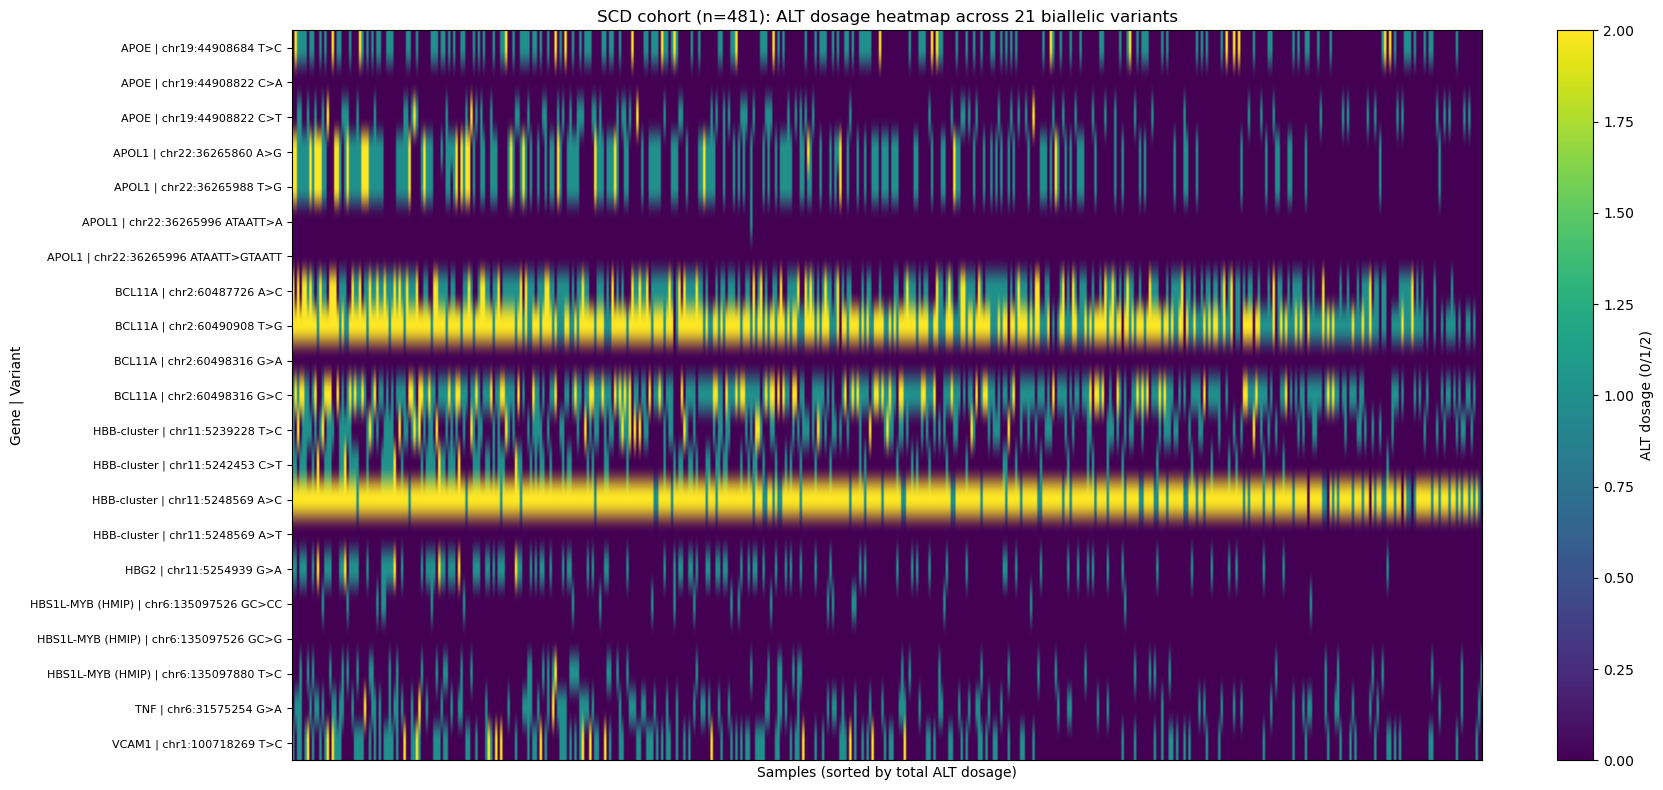

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load long genotypes
long_df = pd.read_csv("ALL_481_genotypes_long.csv")

# --------------------------------------------------
# Gene annotation
# --------------------------------------------------

gene_map = {
    ("chr19", 44908684): "APOE",
    ("chr19", 44908822): "APOE",

    ("chr22", 36265860): "APOL1",
    ("chr22", 36265988): "APOL1",
    ("chr22", 36265996): "APOL1",

    ("chr2", 60487726): "BCL11A",
    ("chr2", 60490908): "BCL11A",
    ("chr2", 60498316): "BCL11A",

    ("chr11", 5239228): "HBB-cluster",
    ("chr11", 5242453): "HBB-cluster",
    ("chr11", 5248569): "HBB-cluster",
    ("chr11", 5254939): "HBG2",

    ("chr6", 31575254): "TNF",
    ("chr6", 135097526): "HBS1L-MYB (HMIP)",
    ("chr6", 135097880): "HBS1L-MYB (HMIP)",

    ("chr1", 100718269): "VCAM1",
}

long_df["GENE"] = long_df.apply(
    lambda r: gene_map.get((r["CHROM"], int(r["POS"])), "UNKNOWN"),
    axis=1
)

# --------------------------------------------------
# Variant label INCLUDING gene name
# --------------------------------------------------

def variant_label(r):
    return (
        f"{r['GENE']} | "
        f"{r['CHROM']}:{int(r['POS'])} "
        f"{r['REF']}>{r['ALT']}"
    )

long_df["VARIANT"] = long_df.apply(variant_label, axis=1)

# --------------------------------------------------
# Convert GT -> dosage
# --------------------------------------------------

def gt_to_dosage(gt):
    if pd.isna(gt):
        return np.nan

    gt = str(gt)

    if gt in ("./.", ".|.", "."):
        return np.nan

    sep = "|" if "|" in gt else ("/" if "/" in gt else None)

    if sep is None:
        return np.nan

    a, b = gt.split(sep)

    if not (a.isdigit() and b.isdigit()):
        return np.nan

    return (a == "1") + (b == "1")

long_df["DOSAGE"] = long_df["GT"].apply(gt_to_dosage)

# --------------------------------------------------
# Pivot matrix
# --------------------------------------------------

mat = long_df.pivot_table(
    index="VARIANT",
    columns="SAMPLE",
    values="DOSAGE",
    aggfunc="first"
)

# Sort samples by total ALT dosage
sample_order = mat.sum(axis=0).sort_values(ascending=False).index
mat = mat[sample_order]

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(18, 8))

plt.imshow(
    mat.values,
    aspect="auto"
)

plt.colorbar(label="ALT dosage (0/1/2)")

plt.yticks(
    range(len(mat.index)),
    mat.index,
    fontsize=8
)

plt.xticks([])

plt.title(
    "SCD cohort (n=481): ALT dosage heatmap across 21 biallelic variants"
)

plt.xlabel(
    "Samples (sorted by total ALT dosage)"
)

plt.ylabel(
    "Gene | Variant"
)

plt.tight_layout()

plt.savefig(
    "SCD_481_variant_heatmap_with_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Saved: SCD481_gene_dosage_matrix.csv
Shape: (8, 481)


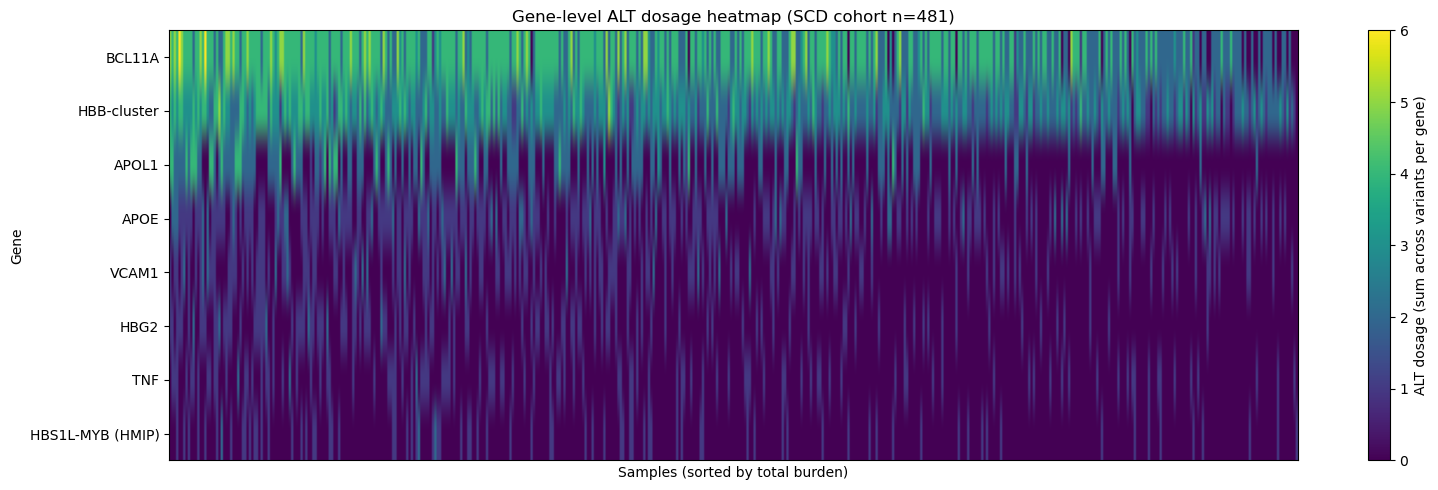

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) Load long format ----
long_df = pd.read_csv("ALL_481_genotypes_long.csv")

# ---- 2) Gene map ----
gene_map = {
    ("chr19", 44908684): "APOE",
    ("chr19", 44908822): "APOE",

    ("chr22", 36265860): "APOL1",
    ("chr22", 36265988): "APOL1",
    ("chr22", 36265996): "APOL1",

    ("chr2", 60487726): "BCL11A",
    ("chr2", 60490908): "BCL11A",
    ("chr2", 60498316): "BCL11A",

    ("chr11", 5239228): "HBB-cluster",
    ("chr11", 5242453): "HBB-cluster",
    ("chr11", 5248569): "HBB-cluster",
    ("chr11", 5254939): "HBG2",

    ("chr6", 31575254): "TNF",
    ("chr6", 135097526): "HBS1L-MYB (HMIP)",
    ("chr6", 135097880): "HBS1L-MYB (HMIP)",

    ("chr1", 100718269): "VCAM1",
}

long_df["POS"] = long_df["POS"].astype(int)
long_df["GENE"] = long_df.apply(
    lambda r: gene_map.get((r["CHROM"], r["POS"]), "UNKNOWN"),
    axis=1
)

# ---- 3) GT -> dosage ----
def gt_to_dosage(gt):
    if pd.isna(gt):
        return np.nan

    gt = str(gt)
    if gt in ("./.", ".|.", "."):
        return np.nan

    sep = "|" if "|" in gt else ("/" if "/" in gt else None)
    if sep is None:
        return np.nan

    a, b = gt.split(sep)

    if not (a.isdigit() and b.isdigit()):
        return np.nan

    return (a == "1") + (b == "1")

long_df["DOSAGE"] = long_df["GT"].apply(gt_to_dosage)

# ---- 4) Gene burden matrix ----
gene_mat = (
    long_df
    .groupby(["GENE", "SAMPLE"])["DOSAGE"]
    .sum()
    .unstack()
    .fillna(0)
)

# ---- 5) Optional normalization (important choice) ----
# Uncomment if you want per-gene average burden instead of raw sum
# gene_mat = gene_mat.div(gene_mat.shape[1], axis=0)

# ---- 6) Sort for interpretability ----
sample_order = gene_mat.sum(axis=0).sort_values(ascending=False).index
gene_mat = gene_mat[sample_order]

gene_order = gene_mat.sum(axis=1).sort_values(ascending=False).index
gene_mat = gene_mat.loc[gene_order]

# ---- 7) Save ----
gene_mat.to_csv("SCD481_gene_dosage_matrix.csv")
print("Saved: SCD481_gene_dosage_matrix.csv")
print("Shape:", gene_mat.shape)

# ---- 8) Plot ----
plt.figure(figsize=(16, 5))

plt.imshow(gene_mat.values, aspect="auto")
plt.colorbar(label="ALT dosage (sum across variants per gene)")

plt.yticks(range(len(gene_mat.index)), gene_mat.index, fontsize=10)
plt.xticks([])

plt.title("Gene-level ALT dosage heatmap (SCD cohort n=481)")
plt.xlabel("Samples (sorted by total burden)")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

In [59]:
import numpy as np
import pandas as pd

n_samples = gene_mat.shape[1]

gene_summary = pd.DataFrame({
    "GENE": gene_mat.index,

    # number of samples
    "N_SAMPLES": n_samples,

    # carriers (at least one ALT allele)
    "N_CARRIERS_anyALT": (gene_mat > 0).sum(axis=1).astype(int),

    # carrier frequency
    "CARRIER_FREQ": (gene_mat > 0).sum(axis=1) / n_samples,

    # total ALT alleles (sum of dosages)
    "TOTAL_ALT_ALLELES": gene_mat.sum(axis=1),

    # ALT allele frequency (true genetic AF)
    "ALT_AF": gene_mat.sum(axis=1) / (2 * n_samples),

    # summary stats
    "MEAN_DOSAGE": gene_mat.mean(axis=1),
    "MEDIAN_DOSAGE": gene_mat.median(axis=1),
    "MAX_DOSAGE": gene_mat.max(axis=1),
    "TOTAL_DOSAGE": gene_mat.sum(axis=1),

}).sort_values(["CARRIER_FREQ", "TOTAL_ALT_ALLELES"], ascending=False)

gene_summary.to_csv("SCD481_gene_summary_with_freqs.csv", index=False)

print("Saved: SCD481_gene_summary_with_freqs.csv")
gene_summary

Saved: SCD481_gene_summary_with_freqs.csv


,GENE,N_SAMPLES,N_CARRIERS_anyALT,CARRIER_FREQ,TOTAL_ALT_ALLELES,ALT_AF,MEAN_DOSAGE,MEDIAN_DOSAGE,MAX_DOSAGE,TOTAL_DOSAGE
GENE,,,,,,,,,,
HBB-cluster,HBB-cluster,481,475,0.987526,1200,1.247401,2.494802,2.0,5,1200
BCL11A,BCL11A,481,455,0.945946,1514,1.573805,3.147609,4.0,6,1514
APOE,APOE,481,252,0.523909,289,0.300416,0.600832,1.0,2,289
APOL1,APOL1,481,185,0.384615,423,0.439709,0.879418,0.0,4,423
VCAM1,VCAM1,481,149,0.309771,166,0.172557,0.345114,0.0,2,166
HBG2,HBG2,481,112,0.232848,118,0.122661,0.245322,0.0,2,118
TNF,TNF,481,110,0.228690,113,0.117464,0.234927,0.0,2,113
HBS1L-MYB (HMIP),HBS1L-MYB (HMIP),481,80,0.166320,83,0.086279,0.172557,0.0,2,83


In [30]:
%%bash
bcftools query -l merged.481.biallelic.vcf.gz | wc -l

481


In [33]:
%%bash
bcftools query -f '[%GT\t]\n' merged.481.biallelic.vcf.gz | \
grep -o '\./\.' | wc -l || true

0


In [ ]:
Plink - do sample/varaint missingness - what use next 

In [ ]:
PCA (ancestry - just for QC not much else) and relatedness (see if siblings etc - remove?). 

In [ ]:
combine with pheno 

In [ ]:
carrier freq vs non carrier freg and complication and lab data and stats 

In [ ]:
machine learning? ask cogstack  

In [ ]:
old cluster - pheno only get gagan code 

In [ ]:
new cluster - add geno ? and compare the two - are the clusters better?

In [ ]:
done? 